In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                if neighbor not in visited and random.random() <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
        current = next_level
        if current:
            time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0
    total_factor = len(visited) / len(available_nodes) if available_nodes else 0

    return spread_time, spread_factor, time, total_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor, time, total_factor = data[0], data[1], data[2], data[3]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
            data_by_k[k]["total_factor"].append(total_factor)
            data_by_k[k]["time"].append(time)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
for generation in [8]:
    if not os.path.exists(f"fig_data/fig12/fig12_g{generation:02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        APL_path = f"data/apl/apl_network_g{generation:02d}.pkl"
        APL_graph = load_graphs(APL_path)
        print(f"Running simulation for generation={generation:02d}:")
        for graph in tqdm([APL_graph]):
            graph_result = run_simulation_by_k(graph, hop=0)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del APL_graph
        save_results(result, f"fig_data/fig12/fig12_g{generation:02d}.pkl")
        del result

Running simulation for generation=08:


100%|██████████| 1/1 [00:47<00:00, 47.40s/it]


Fig 12a


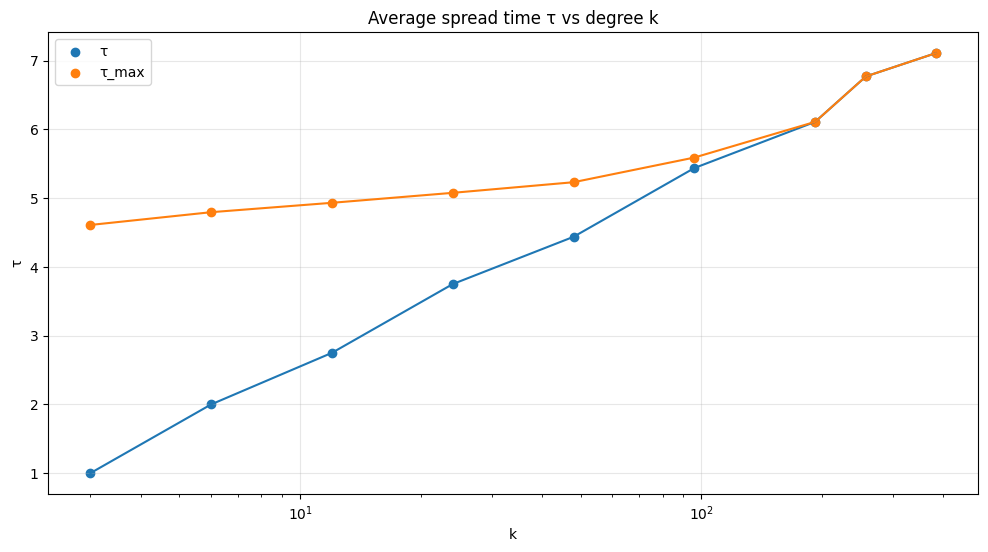

In [8]:
import matplotlib.pyplot as plt
import numpy as np

#Spread time
plt.figure(figsize=(12, 6))
APL_data_by_k = load_graphs(f"fig_data/fig12/fig12_g08.pkl")
APL_plot_data_by_k = defaultdict(dict)
for k in APL_data_by_k:
    APL_plot_data_by_k[k]["spread_time"] = sum(APL_data_by_k[k]["spread_time"]) / len(APL_data_by_k[k]["spread_time"])
ks = np.array(sorted(APL_plot_data_by_k))
spread_times = np.array([APL_plot_data_by_k[k]["spread_time"] for k in ks])

plt.plot(ks, spread_times)
plt.scatter(ks, spread_times, label="τ")
del APL_data_by_k, APL_plot_data_by_k

#Max time
APL_data_by_k = load_graphs(f"fig_data/fig12/fig12_g08.pkl")
APL_plot_data_by_k = defaultdict(dict)
for k in APL_data_by_k:
    APL_plot_data_by_k[k]["time"] = sum(APL_data_by_k[k]["time"]) / len(APL_data_by_k[k]["time"])
ks = np.array(sorted(APL_plot_data_by_k))
spread_times = np.array([APL_plot_data_by_k[k]["time"] for k in ks])

plt.plot(ks, spread_times)
plt.scatter(ks, spread_times, label="τ_max")
del APL_data_by_k, APL_plot_data_by_k

print("Fig 12a")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 12b


C:\Users\HP\AppData\Local\Temp\ipykernel_18504\1152529300.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


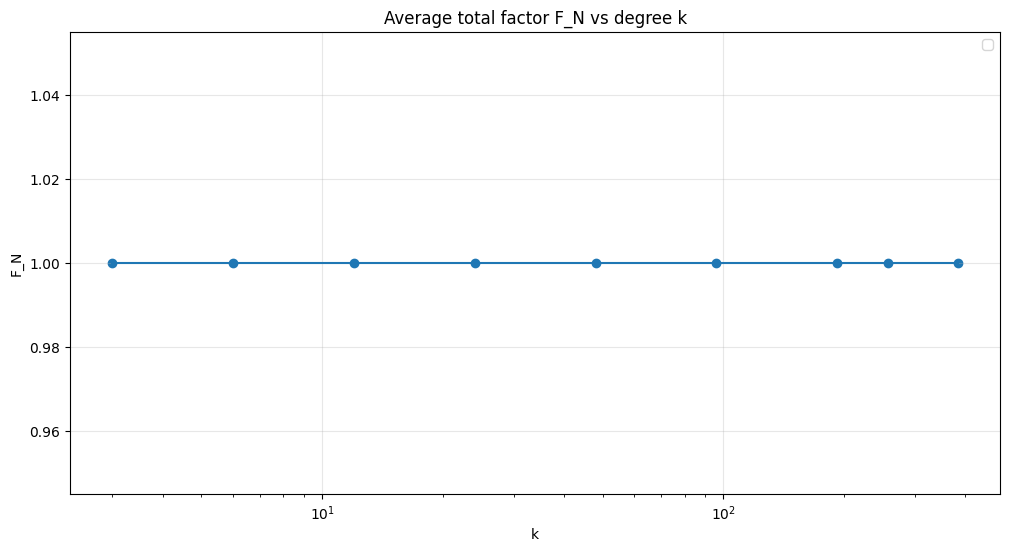

In [12]:
#Spread factor
plt.figure(figsize=(12, 6))
APL_data_by_k = load_graphs(f"fig_data/fig12/fig12_g08.pkl")
APL_plot_data_by_k = defaultdict(dict) 
for k in APL_data_by_k: 
    APL_plot_data_by_k[k]["total_factor"] = sum(APL_data_by_k[k]["total_factor"]) / len(APL_data_by_k[k]["total_factor"])
ks = sorted(APL_plot_data_by_k)
spread_factors = [APL_plot_data_by_k[k]["total_factor"]for k in ks]
plt.scatter(ks, spread_factors)
plt.plot(ks, spread_factors)
del APL_data_by_k, APL_plot_data_by_k

print("Fig 12b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("F_N")
plt.title("Average total factor F_N vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()